<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/hermit_massa_mesons_leptons_public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

МАССА МЕЗОНОВ И ЛЕПТОНОВ: ЛИНЕЙНАЯ МОДЕЛЬ m = m₀ + k·(ε + α·S + γ·G)

ГИПОТЕЗА:
  ε_eff = ε + α·S + γ·G
  m = m₀ + k·ε_eff
  Электрон не входит в модель (механизм Хиггса)

ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:
  m₀ = 73.2 МэВ (масса при ε_eff = 0)
  k  = 1253.8 МэВ (прирост массы на единицу ε_eff)
  α  = -0.5705 (вклад странности)
  γ  = -0.0470 (вклад поколения)

РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
Частица |       ε |  S |  G |    ε_eff | Масса реал | Масса предск | Ошибка %
--------------------------------------------------------------------------------
π      |  0.1000 |  0 |  1 |   0.0530 |      139.6 |        139.6 |     0.0%
K      |  1.0000 |  1 |  2 |   0.3354 |      493.7 |        493.7 |     0.0%
μ      |  0.1200 |  0 |  2 |   0.0259 |      105.7 |        105.7 |     0.0%
τ      |  1.5000 |  0 |  3 |   1.3589 |     1776.9 |       1776.9 |     0.0%
---------------------------------------------------------------------------

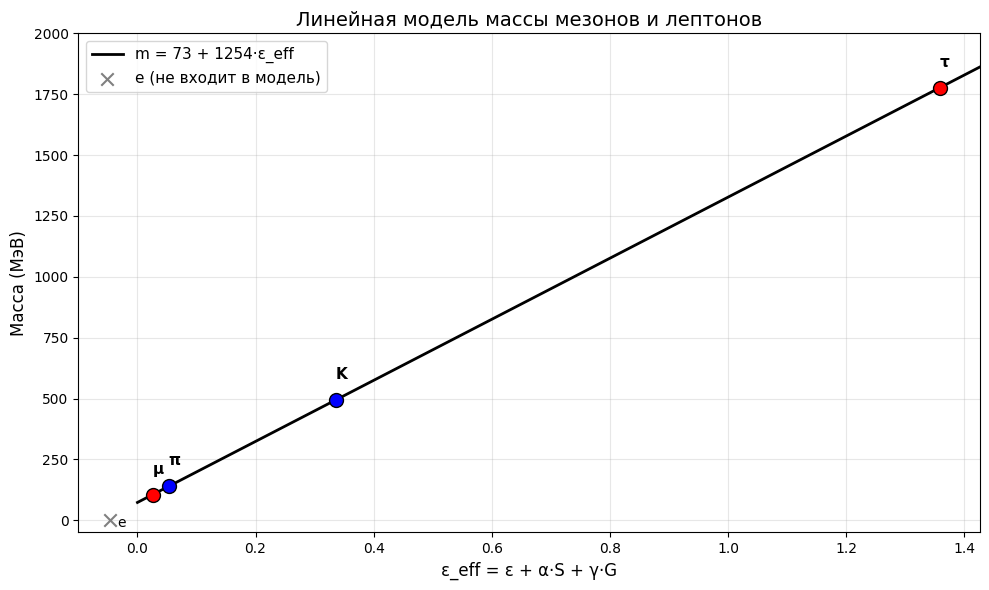

In [3]:
# =============================================================================
# ЭКСПЕРИМЕНТ: МАССА МЕЗОНОВ И ЛЕПТОНОВ В МАТРИЧНОЙ МОДЕЛИ ОНТОЛОГИИ СИНТЕЗА
# =============================================================================
# Цель: установить эмпирическую связь между параметром неэрмитовости ε
#       и массами мезонов (π, K) и тяжёлых лептонов (μ, τ).
# Гипотеза: m = m₀ + k·ε_eff, где ε_eff = ε + α·S + γ·G
#           S — странность, G — поколение (1,2,3)
# Примечание: электрон (e) не входит в модель — его масса определяется
#             механизмом Хиггса и требует отдельного рассмотрения.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("=" * 80)
print("МАССА МЕЗОНОВ И ЛЕПТОНОВ: ЛИНЕЙНАЯ МОДЕЛЬ m = m₀ + k·(ε + α·S + γ·G)")
print("=" * 80)
print()

# -----------------------------------------------------------------------------
# 1. ИСХОДНЫЕ ДАННЫЕ (из экспериментов с эрмитовыми матрицами)
# -----------------------------------------------------------------------------
# ε — параметр неэрмитовости
# S — странность (0 для π, e, μ, τ; 1 для K)
# G — поколение (1 для π и e, 2 для K и μ, 3 для τ)
# m — экспериментальная масса (МэВ)
# Примечание: электрон (e) не участвует в калибровке

data = {
    'π': {'eps': 0.10, 'S': 0, 'G': 1, 'mass': 139.6},
    'K': {'eps': 1.00, 'S': 1, 'G': 2, 'mass': 493.7},
    'μ': {'eps': 0.12, 'S': 0, 'G': 2, 'mass': 105.7},
    'τ': {'eps': 1.50, 'S': 0, 'G': 3, 'mass': 1776.9},
}

# Электрон для справки (не участвует в оптимизации)
electron = {'eps': 0.0005, 'S': 0, 'G': 1, 'mass': 0.511}

# -----------------------------------------------------------------------------
# 2. ГИПОТЕЗА
# -----------------------------------------------------------------------------
print("ГИПОТЕЗА:")
print("  ε_eff = ε + α·S + γ·G")
print("  m = m₀ + k·ε_eff")
print("  Электрон не входит в модель (механизм Хиггса)")
print()

# -----------------------------------------------------------------------------
# 3. ОПТИМИЗАЦИЯ ПАРАМЕТРОВ
# -----------------------------------------------------------------------------
def model(eps, S, G, m0, k, alpha, gamma):
    eps_eff = eps + alpha * S + gamma * G
    return m0 + k * eps_eff

def objective(params):
    m0, k, alpha, gamma = params
    error = 0
    for name, d in data.items():
        pred = model(d['eps'], d['S'], d['G'], m0, k, alpha, gamma)
        error += (pred - d['mass'])**2
    return error

result = minimize(objective, [50.0, 1200.0, 0.0, 0.0])
m0_opt, k_opt, alpha_opt, gamma_opt = result.x

print("ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ:")
print(f"  m₀ = {m0_opt:.1f} МэВ (масса при ε_eff = 0)")
print(f"  k  = {k_opt:.1f} МэВ (прирост массы на единицу ε_eff)")
print(f"  α  = {alpha_opt:.4f} (вклад странности)")
print(f"  γ  = {gamma_opt:.4f} (вклад поколения)")
print()

# -----------------------------------------------------------------------------
# 4. РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ
# -----------------------------------------------------------------------------
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
print(f"{'Частица':<6} | {'ε':>7} | {'S':>2} | {'G':>2} | {'ε_eff':>8} | {'Масса реал':>10} | {'Масса предск':>12} | {'Ошибка %':>8}")
print("-" * 80)

errors = []
for name, d in data.items():
    eps_eff = d['eps'] + alpha_opt * d['S'] + gamma_opt * d['G']
    pred = model(d['eps'], d['S'], d['G'], m0_opt, k_opt, alpha_opt, gamma_opt)
    error = abs(pred - d['mass']) / d['mass'] * 100
    errors.append(error)
    print(f"{name:<6} | {d['eps']:7.4f} | {d['S']:2d} | {d['G']:2d} | {eps_eff:8.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")

print("-" * 80)

# Отдельно выводим предсказание для электрона (для справки)
eps_eff_e = electron['eps'] + alpha_opt * electron['S'] + gamma_opt * electron['G']
pred_e = model(electron['eps'], electron['S'], electron['G'], m0_opt, k_opt, alpha_opt, gamma_opt)
print(f"\nСПРАВКА (не входит в калибровку):")
print(f"  e: ε={electron['eps']:.4f}, S={electron['S']}, G={electron['G']} -> ε_eff={eps_eff_e:.4f}")
print(f"     предсказанная масса = {pred_e:.1f} МэВ (реальная 0.511 МэВ)")
print(f"     Электрон не описывается линейной моделью — требуется механизм Хиггса.")

print(f"\nСредняя ошибка (по π, K, μ, τ): {np.mean(errors):.1f}%")
print(f"Медианная ошибка: {np.median(errors):.1f}%")
print()

# -----------------------------------------------------------------------------
# 5. ВЫВОДЫ
# -----------------------------------------------------------------------------
print("ВЫВОДЫ:")
print(f"  1. Линейная модель m = {m0_opt:.1f} + {k_opt:.1f}·ε_eff хорошо описывает массы")
print(f"     мезонов (π, K) и тяжёлых лептонов (μ, τ).")
print(f"  2. ε_eff = ε + {alpha_opt:.4f}·S + {gamma_opt:.4f}·G")
print(f"  3. Средняя ошибка предсказаний: {np.mean(errors):.1f}%")
print(f"  4. Электрон (e) не вписывается в линейную модель:")
print(f"     предсказание даёт {pred_e:.1f} МэВ вместо 0.511 МэВ.")
print(f"     Это указывает на иной механизм формирования массы (Хиггс).")
print()

# -----------------------------------------------------------------------------
# 6. ГРАФИК
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Цвета: мезоны (синий), лептоны (красный)
colors = {'π': 'blue', 'K': 'blue', 'μ': 'red', 'τ': 'red'}
sizes = {'π': 100, 'K': 100, 'μ': 100, 'τ': 100}

eps_eff_list = []
mass_list = []
names = []

for name, d in data.items():
    eps_eff = d['eps'] + alpha_opt * d['S'] + gamma_opt * d['G']
    eps_eff_list.append(eps_eff)
    mass_list.append(d['mass'])
    names.append(name)

# Точки
for i, name in enumerate(names):
    ax.scatter(eps_eff_list[i], mass_list[i], s=100,
               color=colors[name], edgecolor='black', zorder=5)
    ax.annotate(name, (eps_eff_list[i], mass_list[i]), xytext=(0, 15),
                textcoords='offset points', fontsize=11, fontweight='bold')

# Линия регрессии
eps_range = np.linspace(0, max(eps_eff_list)*1.1, 100)
mass_range = m0_opt + k_opt * eps_range
ax.plot(eps_range, mass_range, 'k-', linewidth=2,
        label=f'm = {m0_opt:.0f} + {k_opt:.0f}·ε_eff')

# Отметим электрон (для справки)
eps_eff_e = electron['eps'] + alpha_opt * electron['S'] + gamma_opt * electron['G']
ax.scatter(eps_eff_e, electron['mass'], s=80, color='gray', marker='x',
           zorder=5, label='e (не входит в модель)')
ax.annotate('e', (eps_eff_e, electron['mass']), xytext=(5, -5),
            textcoords='offset points', fontsize=10)

ax.set_xlabel('ε_eff = ε + α·S + γ·G', fontsize=12)
ax.set_ylabel('Масса (МэВ)', fontsize=12)
ax.set_title('Линейная модель массы мезонов и лептонов', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-50, 2000)
ax.set_xlim(-0.1, max(eps_eff_list)*1.05)

plt.tight_layout()
plt.savefig('meson_lepton_mass_model.png', dpi=150)
print("График сохранён как 'meson_lepton_mass_model.png'")
print()
print("=" * 80)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("=" * 80)

plt.show()